In [11]:
import os
import io
import numpy as np
import json

from pyxtal import pyxtal
from scipy.fft import fft, fft2, fftshift

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

# "name" = wallpaper group name, 
# "layer_no" = 3D extension (layer group number), 
# "no_atoms" = bounds for number of atoms in UC, 
# "even" = shoud number of atoms in UC be even?
wallpaper_groups = {1:  {"name" : "p1",   "layer_no" : 1,  "no_atoms" : [1, 10], "even" : False}, 
                    2:  {"name" : "p2",   "layer_no" : 3,  "no_atoms" : [3, 10], "even" : False},
                    3:  {"name" : "pm",   "layer_no" : 11, "no_atoms" : [3, 10], "even" : False},
                    4:  {"name" : "pg",   "layer_no" : 12, "no_atoms" : [4, 10], "even" : True}, 
                    5:  {"name" : "pmm",  "layer_no" : 23, "no_atoms" : [4, 16], "even" : False},
                    6:  {"name" : "pmg",  "layer_no" : 24, "no_atoms" : [4, 16], "even" : True},
                    7:  {"name" : "pgg",  "layer_no" : 25, "no_atoms" : [4, 16], "even" : True},
                    8:  {"name" : "cm",   "layer_no" : 13, "no_atoms" : [4, 16], "even" : True},
                    9:  {"name" : "cmm",  "layer_no" : 26, "no_atoms" : [4, 16], "even" : True},
                    10: {"name" : "p4",   "layer_no" : 49, "no_atoms" : [4, 20], "even" : True},
                    11: {"name" : "p4m",  "layer_no" : 55, "no_atoms" : [4, 20], "even" : True},
                    12: {"name" : "p4g",  "layer_no" : 56, "no_atoms" : [4, 20], "even" : True},
                    13: {"name" : "p3",   "layer_no" : 65, "no_atoms" : [4, 20], "even" : True},
                    14: {"name" : "p3m1", "layer_no" : 69, "no_atoms" : [4, 20], "even" : True},
                    15: {"name" : "p31m", "layer_no" : 70, "no_atoms" : [4, 20], "even" : True},
                    16: {"name" : "p6",   "layer_no" : 73, "no_atoms" : [6, 20], "even" : True},
                    17: {"name" : "p6m",  "layer_no" : 77, "no_atoms" : [6, 20], "even" : True}}

sorted_groups = {"p1": 0, "p2": 1, "pg": 2, "pm": 3, "cm": 4, "pgg": 5, "pmg": 6, "pmm": 7, "cmm": 8,
                 "p4": 9, "p4g": 10, "p4m": 11, "p3": 12, "p3m1": 13, "p31m": 14, "p6": 15, "p6m": 16}

                            
def random_wallpaper():
    return np.random.randint(17)+1


class RandomLattice:
    
    def __init__(self, supercell=[10,10,1], max_rotation_angle=90, atom_radius=.3, scale=1., path=None):

        assert os.path.isdir(path), "Path to save the generated images does not exist."
        self.path = path
        self.max_rotation_angle = max_rotation_angle
        self.supercell = supercell
        self.atom_radius = atom_radius
        self.scale = scale
        self.group = None
        
    def generate_lattice(self, wallpaper_class):
        
        self.group = wallpaper_groups[wallpaper_class]
        # randomize no of atoms in UC
        min_no_atoms_in_UC, max_no_atoms_in_UC = self.group["no_atoms"]
        if self.group["even"]:
            rand_bounds = [int(min_no_atoms_in_UC/2), int(max_no_atoms_in_UC/2)]
            rand_multiplier = 2
        else:
            rand_bounds = [min_no_atoms_in_UC, max_no_atoms_in_UC]
            rand_multiplier = 1
        no_atoms_in_UC = np.random.randint(rand_bounds[0], rand_bounds[1]+1)*rand_multiplier
        # define random crystal
        xtal = pyxtal()
        xtal.from_random(2, self.group["layer_no"], ['C'], [no_atoms_in_UC], thickness=2.)
        ase_lattice = xtal.to_ase()*self.supercell
        ase_lattice.rotate(np.random.randint(self.max_rotation_angle)+1, 'z')
        return ase_lattice, self.group["name"]

    def render_lattice(self, ase_lattice, sample_name=None, title=False, return_ndarray=True):

        fig, ax = plt.subplots()
        fig.set_size_inches(5., 5.)
        plot_atoms(ase_lattice, ax, radii=self.atom_radius, scale=self.scale, show_unit_cell=False) 
        ax.set_axis_off()
        if title is False: fig.tight_layout()
        if return_ndarray:
            io_buf = io.BytesIO()
            fig.savefig(io_buf, format='raw', dpi=200)
            io_buf.seek(0)
            img_arr = np.reshape(np.frombuffer(io_buf.getvalue(), dtype=np.uint8),
                                newshape=(int(fig.bbox.bounds[3])*2, int(fig.bbox.bounds[2])*2, -1))
            io_buf.close()
        if sample_name is not None:
            if title:
                ax.set_title(self.group["name"])
            fig.savefig(os.path.join(self.path, sample_name), dpi=200)
        plt.close()
        if return_ndarray:
            return img_arr[:,:,0]
    
    def fourier_trasform(self, real_image, sample_name=None):
        transform = np.abs(fftshift(fft2(real_image)))
        fig, ax = plt.subplots()
        fig.set_size_inches(5., 5.)
        ax.imshow(transform[400:600,400:600], cmap='gray_r')
        ax.set_axis_off()
        fig.savefig(os.path.join(self.path, sample_name+'_f'), dpi=100)
        
    def fourier_trasform_(self, real_image):
        fft = fftshift(fft2(real_image))
        return np.real(fft), np.imag(fft)     
    
    def dump_labels(self, labels):
        with open(os.path.join(self.path, 'labels.json'), 'w') as fp:
            json.dump(labels, fp)


class RandomLattice1D:
    
    def __init__(self, supercell_size=1000, sigma=1., path=None):
        assert os.path.isdir(path), "Path to save the generated images does not exist."
        self.path = path
        self.supercell_size = supercell_size
        self.grid = np.linspace(0., self.supercell_size, num=self.supercell_size+1, endpoint=True)
        self.sigma = sigma

    def generate_lattice_quasi(self, sublattices=[10,12], offsets=[0,0]):
        density = np.zeros((self.supercell_size+1, len(sublattices)))
        for s, (Rs, offset) in enumerate(zip(sublattices, offsets)):
            no_nodes = int(self.supercell_size/Rs)
            for i in range(no_nodes+1):
                density[:,s] += np.exp(-((self.grid-i*Rs-offset)/self.sigma)**2/2.)
        return density
    
    def fourier_trasform_(self, real_image):
        trans = fftshift(fft(real_image))
        return np.real(trans), np.imag(trans) 


In [39]:
generator = RandomLattice(path='./generated')
lattice, label = generator.generate_lattice(1)

In [67]:
xtal = pyxtal()
layer_group_num = 67
supercell=[10,10,1]
xtal.from_random(2, layer_group_num, ['C'], [5], thickness=2.)
ase_lattice = xtal.to_ase()*supercell

In [68]:
ase_lattice.get_positions()

array([[ 1.46821908e+00,  4.94181053e-01,  7.50000000e+00],
       [ 1.46821908e+00, -4.94181053e-01,  7.50000000e+00],
       [ 2.32416577e+00,  9.89939710e-16,  7.50000000e+00],
       ...,
       [ 2.59968834e+01,  1.36674499e+01,  7.50000000e+00],
       [ 2.36727176e+01,  1.36674499e+01,  8.96754460e+00],
       [ 2.36727176e+01,  1.36674499e+01,  9.03245540e+00]])

<Axes: >

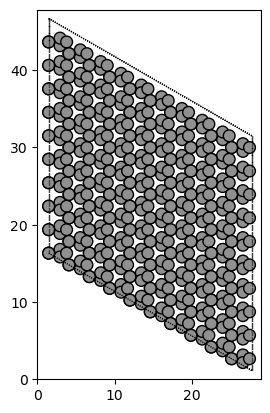

In [69]:
plot_atoms(ase_lattice)

In [ ]:
generator = RandomLattice(path='./generated')

labels = []
no_samples_to_be_generated = 10
for i in range(no_samples_to_be_generated):
    lattice, label = generator.generate_lattice(random_wallpaper())
    labels.append({"file_id": i, "label" : label})
    crystal_render = generator.render_lattice(lattice, sample_name=str(i), title=False)
    generator.fourier_trasform(255-crystal_render, sample_name=str(i))
generator.dump_labels(labels)